In [2]:
import sys

sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

#load the necessary odometry modules
from cpsl_datasets.map_handler import MapHandler
from cpsl_datasets.cpsl_ds import CpslDS
from odometry.test_benches._test_bench import _TestBench
from odometry.localization.icp2D_localization import icp2DLocalization
from odometry.localization._localizer import _Localizer
from odometry.plotting.plotter_kalman import PlotterKalman
from odometry.plotting.movies import MovieGenerator


/home/david/.cache/pypoetry/virtualenvs/odometry-JJ4jnFPp-py3.10/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
from dotenv import load_dotenv
import os

#loading enviroment variables
load_dotenv()
# DATASET_PATH=os.getenv("DATASET_DIRECTORY")
# MAP_DIRECTORY=os.getenv("MAP_DIRECTORY")

DATASET_PATH="/data/Hermes"
MAP_DIRECTORY="/data/Hermes/maps"


#setup the datasets
# folder_name = "WILK"
folder_name = "hermes_cpsl_4"

dataset = CpslDS(
    dataset_path=os.path.join(DATASET_PATH,folder_name),
    radar_folder="front_radar_adc",
    lidar_folder="lidar",
    camera_folder="camera",
    imu_orientation_folder="imu_data",
    imu_full_folder="imu_data_full",
    vehicle_vel_folder="vehicle_vel",
    vehicle_odom_folder="vehicle_odom"
)

map_handler = MapHandler(
    maps_folder=MAP_DIRECTORY,
    map_file="cpsl.yaml"
)

found 596 radar samples
found 595 lidar samples
did not find camera samples
did not find hand tracking samples
did not find imu (orientation) samples
did not find imu (full data) samples
found 595 vehicle velocity samples
found 595 vehicle odometry samples
loaded map from /data/Hermes/maps/cpsl.yaml
loaded map free space from /data/Hermes/maps/cpsl.yaml


In [4]:
lidar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.1, #was 0.6, try 0.1
    icp_best_points_percentile=50, #was 50 - try 75
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=10,
    icp_max_iterations=20,
    self_detection_radius_m=1.0 #was 0.25, try 1.0
)

loaded map with 2677 points
gt icp estimated heading:1.0474294993876694 deg, pose:[ 0.15124181 -0.03978495]


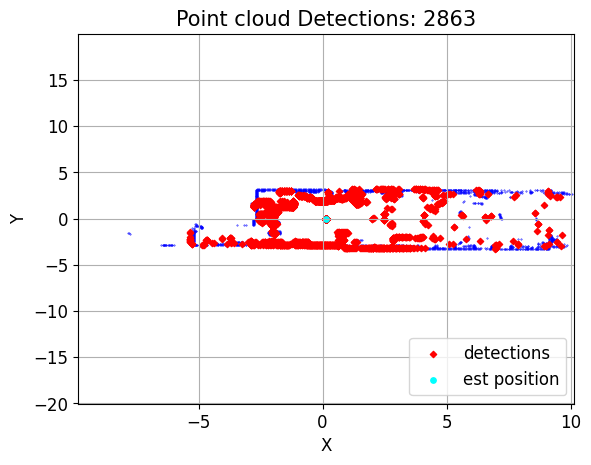

In [5]:
use_filters = False
test_bench = _TestBench(
    gt_localizer=lidar_odometry,
    map_handler=map_handler,
    dataset=dataset,
    use_filters = False,
    use_vehicle_odom = True
)

start_heading = np.deg2rad(0)
start_pose = np.array([0.03,0.11])

#initialize the localization
new_heading_rad,new_pose_m = test_bench.init_localization(
    est_start_heading_rad=start_heading,
    est_start_pose_m=start_pose,
    show=True
)


found temp dir: /home/david/Downloads/radnav_temp_dir
clearing temp directory /home/david/Downloads/radnav_temp_dir


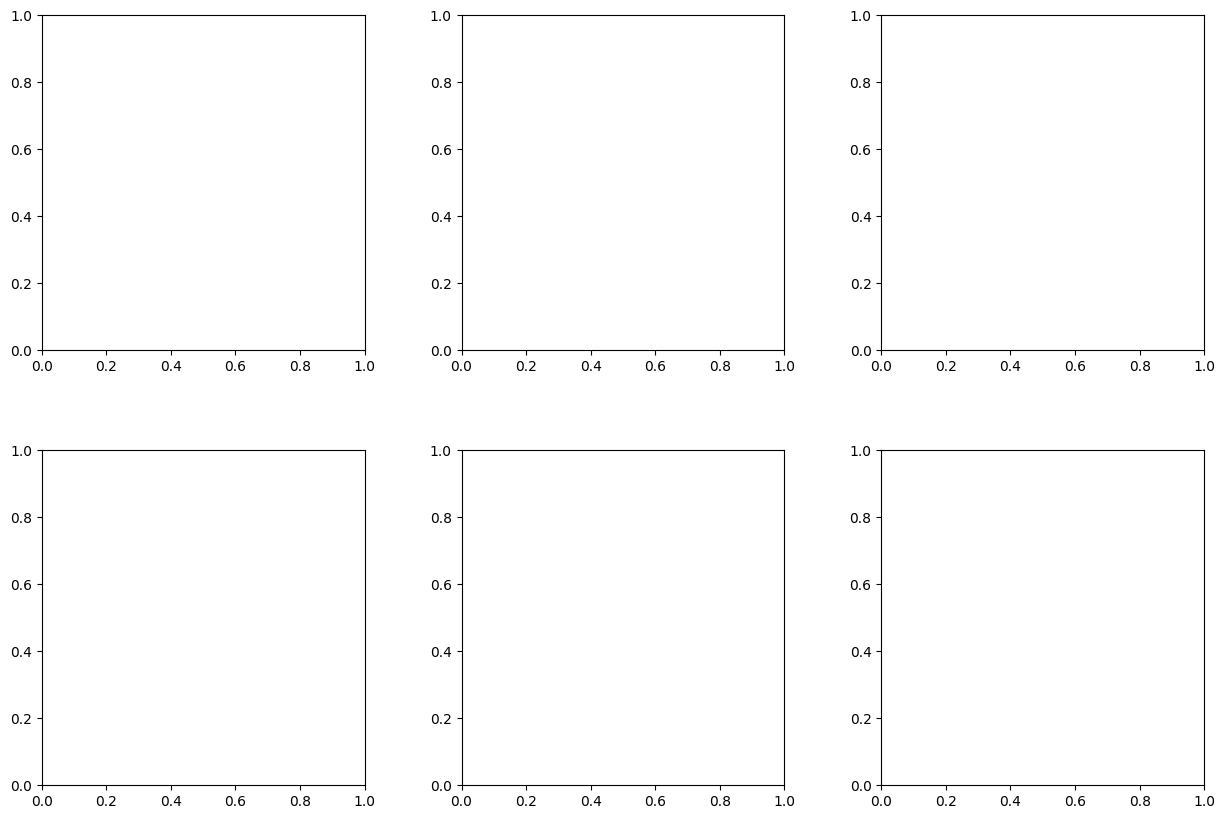

In [6]:
#loading directory from .env file
MOVIE_TEMP_DIRECTORY = os.getenv("MOVIE_TEMP_DIRECTORY")

#initialize the movie maker
movie_generator = MovieGenerator(
    temp_dir_path=MOVIE_TEMP_DIRECTORY
)
movie_generator.initialize_figure(
    nrows=2,
    ncols=3,
    figsize=(15,10)
)

In [7]:
end_idx = dataset.num_frames#dataset.num_frames #dataset.num_frames #point cloud sample: frame 1340 on Wilk_Multipath_test_5
save_name = "{}_hermes"
test_bench.run(
    max_frame=end_idx,
    gt_enabled=True,
    movie_generator=None)

100%|██████████| 595/595 [00:11<00:00, 50.45it/s]


In [1]:
#evaluating processing times
update_periods = np.array(test_bench.history_update_periods)
processing_times = np.array(test_bench.history_update_actitve_compute_times)

percent_processing_times = 100 * np.divide(processing_times, update_periods)
np.save("processing_times/odom_only.npy",percent_processing_times)

NameError: name 'np' is not defined

In [ ]:
np.save("Trajectories/gt.npy",test_bench.history_position_m_gt)
np.save("Trajectories/odom_only.npy",test_bench.history_position_m)

In [ ]:
movie_generator.save_movie(video_file_name="{}.mp4".format(save_name),fps=20)

0it [00:00, ?it/s]


In [ ]:
test_bench.analyze(
    save_folder_path="Results",
    file_name=folder_name,
    export_to_csv=False
)

/home/david/.cache/pypoetry/virtualenvs/odometry-JJ4jnFPp-py3.10/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/david/.cache/pypoetry/virtualenvs/odometry-JJ4jnFPp-py3.10/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/david/.cache/pypoetry/virtualenvs/odometry-JJ4jnFPp-py3.10/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/david/.cache/pypoetry/virtualenvs/odometry-JJ4jnFPp-py3.10/lib/python3.10/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/david/.cache/pypoetry/virtualenvs/odometry-JJ4jnFPp-py3.10/lib/python3.10/site-packages/numpy/core/_me

ValueError: attempt to get argmin of an empty sequence

In [ ]:
test_bench.plot_compilation(
    idx=end_idx-1,
    show=True
)

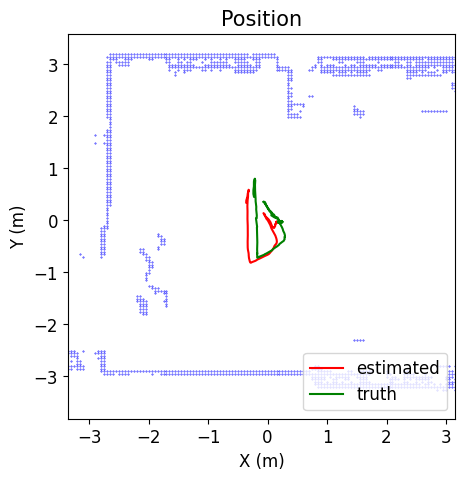

In [8]:
fig, axs = plt.subplots(figsize=(5,5))

test_bench.plotter_localization.plot_position_history_m(
    test_bench.history_position_m,
    test_bench.history_position_m_gt,
    idx=300-1,
    ax=axs,
    show=True
)

fig.savefig("Images/position_history/{}.png".format(save_name))

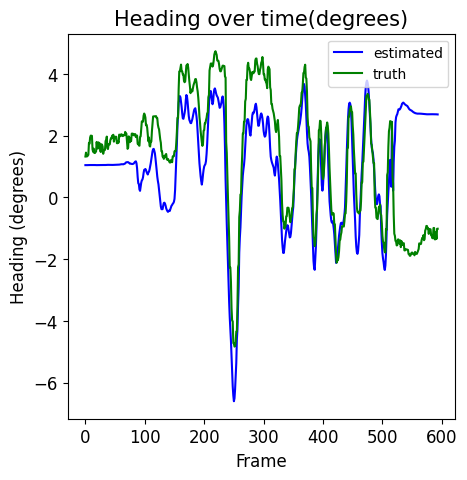

In [ ]:
fig, axs = plt.subplots(figsize=(5,5))

test_bench.plotter_localization.plot_heading_history_deg(
    test_bench.history_heading_deg,
    test_bench.history_heading_deg_gt,
    idx=end_idx-1,
    ax=axs,
    show=True
)

In [ ]:
print(np.rad2deg(test_bench.gt_localizer.current_heading_rad))
print(test_bench.gt_localizer.current_pose_m)

3.1126972033333735
[-0.20940676  0.56324333]


In [ ]:
from geometries.transforms.transformation import Transformation
from geometries.pose.pose import Pose
from geometries.pose.orientation import Orientation
from geometries.pose.position import Position

end_idx = 220

#get the previous frame's odometry information
prev_data = test_bench.dataset.get_vehicle_odom_data(idx=end_idx-1)[-1,1:8] #most recent position estimate
prev_pose = Pose(
    position=Position(
        x=prev_data[0],
        y=prev_data[1],
        z=prev_data[2]
    ),
    orientation=Orientation(
        qw=prev_data[3],
        qx=prev_data[4],
        qy=prev_data[5],
        qz=prev_data[6]
    )
)
# prev_pose = prev_pose.flu_from_ned()
print(prev_pose.orientation.to_euler(degrees=True))
print(prev_pose.position)

cur_data = test_bench.dataset.get_vehicle_odom_data(idx=end_idx)[-1,1:8] #most recent position estimate
cur_pose = Pose(
    position=Position(
        x=cur_data[0],
        y=cur_data[1],
        z=cur_data[2]
    ),
    orientation=Orientation(
        qw=cur_data[3],
        qx=cur_data[4],
        qy=cur_data[5],
        qz=cur_data[6]
    )
)
# cur_pose = cur_pose.flu_from_ned()
#[time,x,y,z,quat_w,quat_x,quat_y,quat_z,vx,vy,vz,wx,wy,wz]
transformation = Transformation.from_orig_to_new(
    original_pose=prev_pose,
    new_pose=cur_pose
)


rotation = transformation.rotation
rotation = Orientation(
    qx=rotation[0],
    qy=rotation[1],
    qz=rotation[2],
    qw=rotation[3]
)

print(transformation.translation)
print(rotation.to_euler(degrees=True)[2])


[178.1348883    0.33137623   2.63399723]
Position(x=-0.14898988604545593, y=-0.545698821544647, z=1.4149930477142334)
[ 0.01301223 -0.01779212 -0.00713425]
-0.09449685794567424


In [ ]:
#compute total distance traveled
dist = 0
for i in range(len(test_bench.history_position_m)-1):
    dist += np.linalg.norm(
        test_bench.history_position_m_gt[i+1] -\
        test_bench.history_position_m_gt[i]
    )

print(dist)

In [ ]:
#plot kalman state history
kalman_plotter = PlotterKalman()

kalman_plotter.plot_kalman_result_history(
    x_history=np.array(test_bench.history_filter_est),
    p_history=np.array(test_bench.history_filter_p),
    idx=-1
)



In [ ]:
gyro_bias_history = np.array(test_bench.history_filter_est)[:,4]
t = np.arange(0,gyro_bias_history.shape[0]) * 1/200
bias = np.rad2deg(0.0024)
error_due_to_bias = bias * 60
print("bias: {} deg/sec, over 1min: {} deg".format(bias,error_due_to_bias))
plt.plot(t,gyro_bias_history)
